## Building with LangGraph


### Building a Chatbot

In [1]:
from langgraph.graph import StateGraph # State management
from typing import Annotated # Validation
from typing_extensions import TypedDict # Validation
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

In [2]:
# Loading the API key from .env
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [3]:
# 1. Create the State object
class State(TypedDict):
    messages: Annotated[list, add_messages] 
    # add_message is an internal function which will append all the messages that are being send to the node.
    # messages is an Annotated list which keeps on growing.

# 2. Create a StateGraph
graph_builder = StateGraph(State)

# 3. Initialise the LLM
llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)

# 4. Define the Node
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

graph = graph_builder.compile()

### Visualizins the Graph

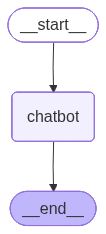

In [4]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# pip install -q grandalf

In [6]:
print(graph.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


### Running the ChatBot

In [7]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye', 'q']:
        print('Goodbye!')
        break

    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print(f"Assistant: {value["messages"][-1].content}")
            print('-' * 20)

User:  quit


Goodbye!


In [1]:
# pip install -q tavily-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [8]:
from tavily import TavilyClient
import os

# Initializing a Tavily client
client = TavilyClient()

response = client.search(query="What is the bitcoin price today?")
response

{'query': 'What is the bitcoin price today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.coindesk.com/price/bitcoin',
   'title': 'Bitcoin price today, BTC to USD live price, marketcap and chart',
   'content': 'The price of Bitcoin (BTC) is $71470.65 today as of Mar 18, 2026, 1:35 pm EDT, with a 24-hour trading volume of $29.87B.',
   'score': 0.99988496,
   'raw_content': None},
  {'url': 'https://coinmarketcap.com/currencies/bitcoin/',
   'title': 'Bitcoin price today, BTC to USD live price, marketcap and chart',
   'content': 'The live Bitcoin price today is $71187.01 USD with a 24-hour trading volume of $43126835714.62 USD. We update our BTC to USD price in real-time.',
   'score': 0.99983394,
   'raw_content': None},
  {'url': 'https://www.binance.com/en/price/bitcoin',
   'title': 'Bitcoin Price Today | BTC to USD Live Price, Market Cap & Chart',
   'content': 'The live price of Bitcoin is $71,289.06 per (BTC / USD) with a cur

In [9]:
# Passing Tavily Results to an LLM using langchain
from langchain_community.adapters.openai import convert_openai_messages
from langchain_openai import ChatOpenAI

query = 'What is the "Reflection & Critique" pattern used in agentic applications and LangGraph?'

response = client.search(query, max_results=5, search_depth='advanced')['results']
response

[{'url': 'https://medium.com/aimonks/reflection-agents-with-langgraph-agentic-llm-based-applications-87e43c27adc7',
  'title': 'Reflection Agents With LangGraph | Agentic LLM Based Applications',
  'content': '## What Is Reflection?\n\nReflection is a prompting strategy used to improve the quality and success rate of agents and similar AI systems. It involves prompting an LLM to reflect on and critique its past actions, sometimes incorporating additional external information such as tools and observations.\n\nImagine an LLM based application like ChatGPT. If you ask it to write you code. It immediately begins to spit out content of the code. Do you know any programmer that just writes code that fast and never tests it, but pushes it into production? Forget about other programmers, just maybe they are that intelligent. Can you personally do that? Of course not, highly unlikely. [...] Code With Prince\n\nThe generator will do the generative part of an LLM, generating answers to user quer

In [10]:
prompt = [
    {
        'role': 'system',
        'content': f'''You are an AI critical thinker research assistant.
        Your sole purpose is to write well written, objective and structured reports on given text.'''
    },
    {
        'role': 'user',
        'content': f'''Information: """{response}"""
        Using the above informtion, answer the following query: """{query}""" in a detailed report'''
    }
]


lc_messages = convert_openai_messages(prompt)
lc_messages

[SystemMessage(content='You are an AI critical thinker research assistant.\n        Your sole purpose is to write well written, objective and structured reports on given text.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Information: """[{\'url\': \'https://medium.com/aimonks/reflection-agents-with-langgraph-agentic-llm-based-applications-87e43c27adc7\', \'title\': \'Reflection Agents With LangGraph | Agentic LLM Based Applications\', \'content\': \'## What Is Reflection?\\n\\nReflection is a prompting strategy used to improve the quality and success rate of agents and similar AI systems. It involves prompting an LLM to reflect on and critique its past actions, sometimes incorporating additional external information such as tools and observations.\\n\\nImagine an LLM based application like ChatGPT. If you ask it to write you code. It immediately begins to spit out content of the code. Do you know any programmer that just writes code that fast and never tests it

In [11]:
llm = ChatOpenAI(model='gpt-4o-mini')
response = llm.invoke(lc_messages)
print(response.content)

### Report on the "Reflection & Critique" Pattern in Agentic Applications and LangGraph

#### Introduction
The "Reflection & Critique" pattern emerges as a pivotal mechanism within agentic artificial intelligence (AI) applications, particularly those utilizing large language models (LLMs) such as GPT-based models. This pattern is designed to enhance the quality, accuracy, and reliability of AI-generated outputs through iterative self-assessment and refinement.

#### Definition of the Reflection & Critique Pattern
The Reflection & Critique pattern can be broadly defined as a systematic process where an AI model undertakes three primary actions:
1. **Generation**: The AI generates an initial output in response to a given prompt.
2. **Self-Reflection**: The AI enters a critique phase wherein it evaluates its own output for quality, consistency, and adherence to predefined constraints.
3. **Iterative Refinement**: Following self-assessment, the AI makes necessary adjustments to the initial

### Adding Tools to the Chatbot

In [3]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [13]:
from langchain_community.tools.tavily_search import TavilySearchResults
tool = TavilySearchResults(max_results=3)
tools = [tool]

C:\Users\ashut\AppData\Local\Temp\ipykernel_5372\2105116558.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=3)


In [14]:
response = tool.invoke("What is gpt o1")
response

[{'title': 'What is GPT-o1? | Glosssary by Tensorway',
  'url': 'https://www.tensorway.com/glossary/gpt-o1',
  'content': 'Glossary\n\n# GPT-o1\n\n## What is GPT-o1?\n\nGPT-o1 is an advanced large language model (LLM) designed by OpenAI to improve reasoning capabilities in generative tasks. It represents a significant evolution in AI by focusing on logical thinking and multi-step problem-solving, addressing limitations in earlier models that primarily focused on generating fluent text.\n\n## Key Features of GPT-o1\n\n Enhanced reasoning: Unlike previous models, GPT-o1 incorporates logical deductions and multi-step problem-solving.\n Context-aware generation: It can generate text that reflects deeper understanding and thought processes.\n\n## Applications of GPT-o1 [...] ## Applications of GPT-o1\n\n Complex problem-solving: GPT-o1 is suited for tasks like code analysis, research, and strategy development.\n Business insights: It enhances decision-making by producing thoughtful, context

In [15]:
# Chatbot Langgraph Code
from langgraph.graph import StateGraph # State management
from typing import Annotated # Validation
from typing_extensions import TypedDict # Validation
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

from langgraph.prebuilt import ToolNode, tools_condition
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
llm_tools = llm.bind_tools(tools)

# Define the Node
def chatbot(state: State):
    return {"messages": [llm_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
### NEW CODE
tool_node = ToolNode(tools=tools)
graph_builder.add_node('tools', tool_node)
# Adding condition edge between tool node and the node
graph_builder.add_conditional_edges(
    'chatbot',
    tools_condition
)

graph_builder.add_edge('tools', 'chatbot')

graph_builder.set_entry_point('chatbot')
# graph_builder.set_finish_point('chatbot')

graph = graph_builder.compile()

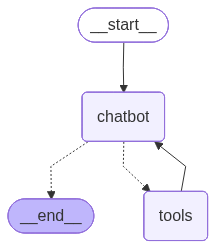

In [16]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye', 'q']:
        print('GoodBye!')
        break

    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print('Assistant: ', value['messages'][-1])

        print('-' * 50)

User:  Who won the swimming gold medal at Paris olympics?


Assistant:  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 90, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_85bc8ad402', 'id': 'chatcmpl-DKbF0FAxUFzIpD1JSDI18cqOoLQ6d', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cfed7-dd0a-7153-aada-a5b01a279576-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'swimming gold medal winner Paris Olympics 2024'}, 'id': 'call_khbW88oZm4pG9SYnDyqDmn4f', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 90, 'output_tokens': 27, 'total_tokens': 117, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

User:  What about Gymnastics?


Assistant:  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 85, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_85bc8ad402', 'id': 'chatcmpl-DKbFEJtO2yKHsS2MF7wbNgafBiz2l', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cfed8-1558-7e70-94fc-9020d7d23655-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Gymnastics news and updates'}, 'id': 'call_ntBKUNqgJ6Hm0Kgs6cGGC2H8', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 85, 'output_tokens': 23, 'total_tokens': 108, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 

User:  quit


GoodBye!


### Adding Memory to the Chatbot

In [17]:
# pip install -q langgraph-checkpoint-sqlite

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Chatbot Langgraph Code
from langgraph.graph import StateGraph # State management
from typing import Annotated # Validation
from typing_extensions import TypedDict # Validation
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools.tavily_search import TavilySearchResults
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
llm_tools = llm.bind_tools(tools)

# Define the Node
def chatbot(state: State):
    return {"messages": [llm_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
### NEW CODE
tool_node = ToolNode(tools=tools)
graph_builder.add_node('tools', tool_node)
# Adding condition edge between tool node and the node
graph_builder.add_conditional_edges(
    'chatbot',
    tools_condition
)

graph_builder.add_edge('tools', 'chatbot')

graph_builder.set_entry_point('chatbot')

In [6]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import MemorySaver

memory = SqliteSaver.from_conn_string(':memory:')
graph = graph_builder.compile(checkpointer=MemorySaver())

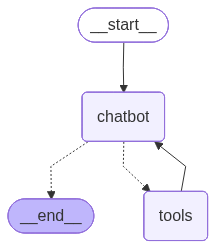

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))
# Notice the graph has not changed after addding the memory

In [8]:
config = {'configurable': {'thread_id': '1'}}

In [9]:
prompt = "Hi! My name is Ash and you are a math tutor."
events = graph.stream(
    {'messages': [('user', prompt)]},
    config, stream_mode='values'
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi! My name is Ash and you are a math tutor.
================================== Ai Message ==================================

Hi Ash! I'm here to help you with any math questions or concepts you need assistance with. What would you like to learn or discuss today?


In [11]:
prompt = "What is my name? What is your role?"
events = graph.stream(
    {'messages': [('user', prompt)]},
    config, stream_mode='values'
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is my name? What is your role?
================================== Ai Message ==================================

Your name is Ash, and my role is to be your math tutor. If you have any math questions or topics you'd like to explore, feel free to ask!


In [12]:
# Testing with a new config id

config_new = {'configurable': {'thread_id': '2'}}
prompt = "What is my name? What is your role?"
events = graph.stream(
    {'messages': [('user', prompt)]},
    config_new, stream_mode='values'
)

for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

What is my name? What is your role?
================================== Ai Message ==================================

I don't have access to personal information about users unless it's shared with me during our conversation. As for my role, I'm here to assist you by answering questions, providing information, and helping with a variety of tasks to the best of my ability. How can I assist you today?


In [17]:
# To check where the current config state is at we can use get_state.
snapshot = graph.get_state(config)

In [18]:
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Hi! My name is Ash and you are a math tutor.', additional_kwargs={}, response_metadata={}, id='600758f7-126c-4c83-beee-0037ad9e679f'), AIMessage(content="Hi Ash! I'm here to help you with any math questions or concepts you need assistance with. What would you like to learn or discuss today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 92, 'total_tokens': 122, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5c64391268', 'id': 'chatcmpl-DKtwBNcUoQ7rjyhTgvkf0RKxWubv2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0320-7ecf-7743-ae3b-c5c13410885b-0', tool_calls=[], invalid_to

In [19]:
# Tells us whats the next node that is going to be called.
# Empty in this case since it has reached an end.
snapshot.next

()